# 🧪 PaySim Fraud Detection — Test & Evaluation Notebook

**Dataset:** [PaySim1 on Kaggle](https://www.kaggle.com/datasets/ealaxi/paysim)  
**Purpose:** Load the trained model from `train_fraud_detection.ipynb` and evaluate it thoroughly on the held-out test set.

> ⚠️ **Prerequisites:** Run `train_fraud_detection.ipynb` first to generate:
> - `fraud_model.pkl` — trained model
> - `scaler.pkl` — fitted scaler
> - `test_data.csv` — held-out test split

---

## 1. 📦 Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    precision_score, recall_score, f1_score,
    matthews_corrcoef, balanced_accuracy_score
)
import joblib
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ Libraries loaded!')

✅ Libraries loaded!


## 2. 📂 Load Model, Scaler & Test Data

In [7]:
# ── Configuration ──────────────────────────────────────────
MODEL_PATH      = 'fraud_model.pkl'
SCALER_PATH     = 'scaler.pkl'
TEST_DATA_PATH  = 'test_data.csv'
TARGET_COL      = 'isFraud'
THRESHOLD       = 0.5     # Decision threshold — adjust to tune Precision/Recall
# ───────────────────────────────────────────────────────────

# Check files exist
for f in [MODEL_PATH, SCALER_PATH, TEST_DATA_PATH]:
    if not os.path.exists(f):
        raise FileNotFoundError(f'❌ Missing file: {f} — Run train_fraud_detection.ipynb first!')

# Load
model  = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

print(f'✅ Model loaded   : {MODEL_PATH}  ({type(model).__name__})')
print(f'✅ Scaler loaded  : {SCALER_PATH}')
print(f'✅ Test data loaded: {test_df.shape[0]:,} rows, {test_df.shape[1]} columns')

# Separate features / target
X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

print(f'\nTest fraud rate: {y_test.mean()*100:.4f}%  '
      f'({y_test.sum():,} fraud out of {len(y_test):,})')

✅ Model loaded   : fraud_model.pkl  (RandomForestClassifier)
✅ Scaler loaded  : scaler.pkl
✅ Test data loaded: 1,272,524 rows, 16 columns

Test fraud rate: 0.1291%  (1,643 fraud out of 1,272,524)


## 3. 🔮 Generate Predictions

In [8]:
# Scale features using the fitted scaler from training
X_test_sc = scaler.transform(X_test)

# Probabilities and class predictions
y_proba = model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= THRESHOLD).astype(int)

print(f'Predictions generated with threshold = {THRESHOLD}')
print(f'Predicted fraud   : {y_pred.sum():,}')
print(f'Predicted not fraud: {(y_pred == 0).sum():,}')

Predictions generated with threshold = 0.5
Predicted fraud   : 1,639
Predicted not fraud: 1,270,885


## 4. 📊 Core Evaluation Metrics

In [9]:
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc  = average_precision_score(y_test, y_proba)
prec    = precision_score(y_test, y_pred)
rec     = recall_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
mcc     = matthews_corrcoef(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)

metrics = {
    'ROC-AUC'           : roc_auc,
    'PR-AUC'            : pr_auc,
    'Precision (Fraud)' : prec,
    'Recall (Fraud)'    : rec,
    'F1-Score (Fraud)'  : f1,
    'MCC'               : mcc,
    'Balanced Accuracy' : bal_acc,
}

print('='*45)
print('   EVALUATION METRICS (Test Set)')
print('='*45)
for k, v in metrics.items():
    bar = '█' * int(v * 20)
    print(f'  {k:<22} {v:.4f}  {bar}')
print('='*45)

print(f'\n📋 Full Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))

   EVALUATION METRICS (Test Set)
  ROC-AUC                0.9994  ███████████████████
  PR-AUC                 0.9987  ███████████████████
  Precision (Fraud)      1.0000  ████████████████████
  Recall (Fraud)         0.9976  ███████████████████
  F1-Score (Fraud)       0.9988  ███████████████████
  MCC                    0.9988  ███████████████████
  Balanced Accuracy      0.9988  ███████████████████

📋 Full Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00   1270881
       Fraud       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



## 5. 📈 ROC & Precision-Recall Curves

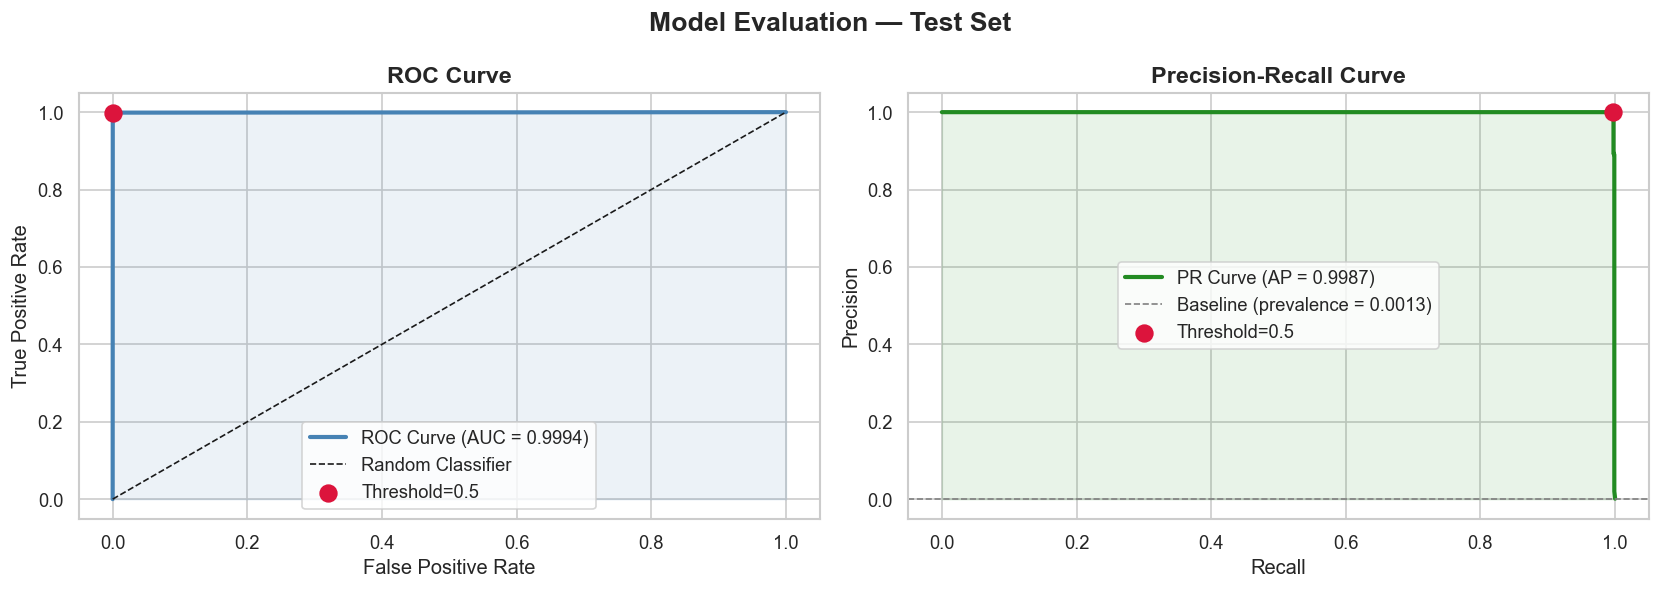

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC Curve ─────────────────────────────────────────────
fpr, tpr, roc_thresh = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='steelblue', lw=2.5,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')

# Mark current threshold
idx = np.argmin(np.abs(roc_thresh - THRESHOLD))
axes[0].scatter(fpr[idx], tpr[idx], color='crimson', zorder=5, s=100,
                label=f'Threshold={THRESHOLD}')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend()

# ── Precision-Recall Curve ─────────────────────────────────
precision_vals, recall_vals, pr_thresh = precision_recall_curve(y_test, y_proba)
axes[1].plot(recall_vals, precision_vals, color='forestgreen', lw=2.5,
             label=f'PR Curve (AP = {pr_auc:.4f})')
axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color='forestgreen')
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', lw=1,
                label=f'Baseline (prevalence = {y_test.mean():.4f})')

# Mark current threshold
idx_pr = np.argmin(np.abs(pr_thresh - THRESHOLD))
axes[1].scatter(recall_vals[idx_pr], precision_vals[idx_pr],
                color='crimson', zorder=5, s=100, label=f'Threshold={THRESHOLD}')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend()

plt.suptitle('Model Evaluation — Test Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves_test.png', bbox_inches='tight')
plt.show()

## 6. 🟦 Confusion Matrix

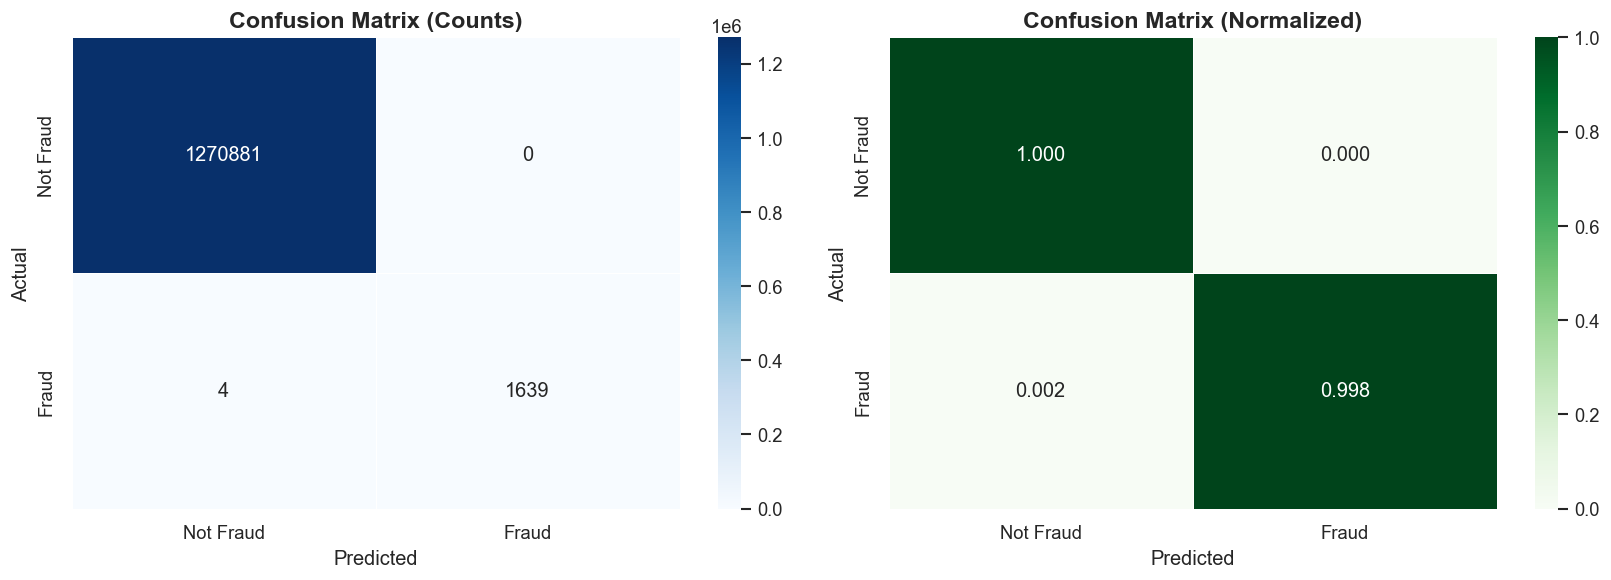


📊 Breakdown:
  ✅ True Negatives  (TN): 1,270,881  — Correctly identified as NOT fraud
  ⚠️  False Positives (FP):        0  — Legitimate flagged as FRAUD
  🚨 False Negatives (FN):        4  — FRAUD missed!
  ✅ True Positives  (TP):    1,639  — Correctly caught FRAUD

  Fraud Catch Rate (Recall): 99.76%
  False Alert Rate          : 0.0000%


In [11]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Greens',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix_test.png', bbox_inches='tight')
plt.show()

print(f'\n📊 Breakdown:')
print(f'  ✅ True Negatives  (TN): {tn:>8,}  — Correctly identified as NOT fraud')
print(f'  ⚠️  False Positives (FP): {fp:>8,}  — Legitimate flagged as FRAUD')
print(f'  🚨 False Negatives (FN): {fn:>8,}  — FRAUD missed!')
print(f'  ✅ True Positives  (TP): {tp:>8,}  — Correctly caught FRAUD')
print(f'\n  Fraud Catch Rate (Recall): {tp/(tp+fn)*100:.2f}%')
print(f'  False Alert Rate          : {fp/(fp+tn)*100:.4f}%')

## 7. 🎚️ Threshold Sensitivity Analysis

Since fraud detection has high asymmetric costs, choosing the right decision threshold is critical.

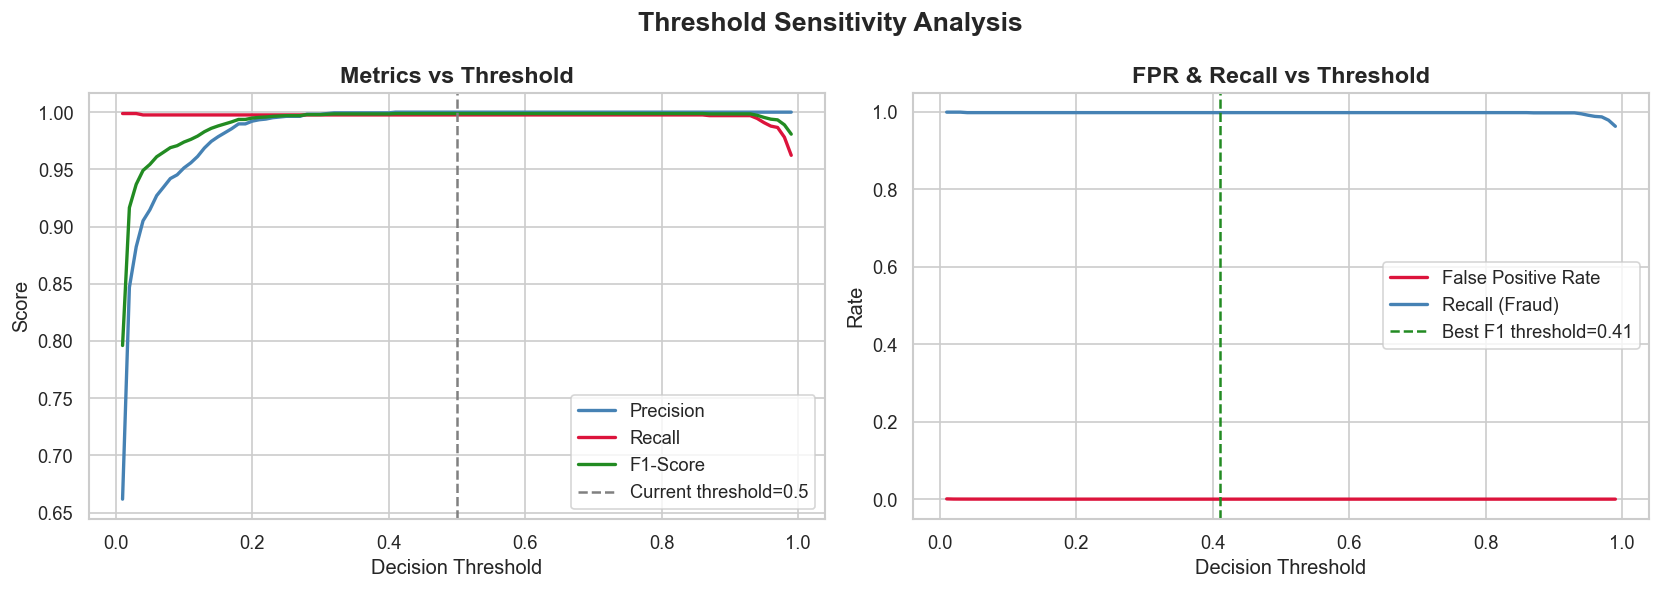


💡 Best F1-Score threshold: 0.41
   F1 at this threshold   : 0.9988
   Precision              : 1.0000
   Recall                 : 0.9976


In [12]:
thresholds = np.linspace(0.01, 0.99, 99)

precisions, recalls, f1s, fprs = [], [], [], []
for t in thresholds:
    y_t = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_t, zero_division=0))
    recalls.append(recall_score(y_test, y_t, zero_division=0))
    f1s.append(f1_score(y_test, y_t, zero_division=0))
    cm_t = confusion_matrix(y_test, y_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    fprs.append(fp_t / (fp_t + tn_t))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision / Recall / F1 vs threshold
axes[0].plot(thresholds, precisions, label='Precision', color='steelblue', lw=2)
axes[0].plot(thresholds, recalls,    label='Recall',    color='crimson',   lw=2)
axes[0].plot(thresholds, f1s,        label='F1-Score',  color='forestgreen',lw=2)
axes[0].axvline(THRESHOLD, color='gray', linestyle='--', label=f'Current threshold={THRESHOLD}')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs Threshold', fontsize=14, fontweight='bold')
axes[0].legend()

# Best F1 threshold
best_f1_idx = np.argmax(f1s)
best_f1_threshold = thresholds[best_f1_idx]

axes[1].plot(thresholds, fprs, color='crimson', lw=2, label='False Positive Rate')
axes[1].plot(thresholds, recalls, color='steelblue', lw=2, label='Recall (Fraud)')
axes[1].axvline(best_f1_threshold, color='forestgreen', linestyle='--',
                label=f'Best F1 threshold={best_f1_threshold:.2f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Rate')
axes[1].set_title('FPR & Recall vs Threshold', fontsize=14, fontweight='bold')
axes[1].legend()

plt.suptitle('Threshold Sensitivity Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('threshold_analysis.png', bbox_inches='tight')
plt.show()

print(f'\n💡 Best F1-Score threshold: {best_f1_threshold:.2f}')
print(f'   F1 at this threshold   : {f1s[best_f1_idx]:.4f}')
print(f'   Precision              : {precisions[best_f1_idx]:.4f}')
print(f'   Recall                 : {recalls[best_f1_idx]:.4f}')

## 8. 🔍 Error Analysis — What Did the Model Miss?

In [13]:
# Attach predictions to test data
analysis_df = X_test.copy()
analysis_df['isFraud']     = y_test.values
analysis_df['y_pred']      = y_pred
analysis_df['fraud_proba'] = y_proba

false_negatives = analysis_df[(analysis_df['isFraud'] == 1) & (analysis_df['y_pred'] == 0)]
false_positives = analysis_df[(analysis_df['isFraud'] == 0) & (analysis_df['y_pred'] == 1)]
true_positives  = analysis_df[(analysis_df['isFraud'] == 1) & (analysis_df['y_pred'] == 1)]

print(f'False Negatives (missed fraud): {len(false_negatives):,}')
print(f'False Positives (false alarms): {len(false_positives):,}')
print(f'True Positives  (caught fraud): {len(true_positives):,}')

print('\n📊 False Negatives — Key Stats (Fraud Missed):')
print(false_negatives[['amount', 'fraud_proba', 'type_encoded']].describe().round(3))

False Negatives (missed fraud): 4
False Positives (false alarms): 0
True Positives  (caught fraud): 1,639

📊 False Negatives — Key Stats (Fraud Missed):
           amount  fraud_proba  type_encoded
count       4.000        4.000          4.00
mean   151546.560        0.018          1.75
std    106688.024        0.021          1.50
min     23292.300        0.000          1.00
25%     98219.288        0.000          1.00
50%    152461.530        0.018          1.00
75%    205788.802        0.036          1.75
max    277970.880        0.038          4.00


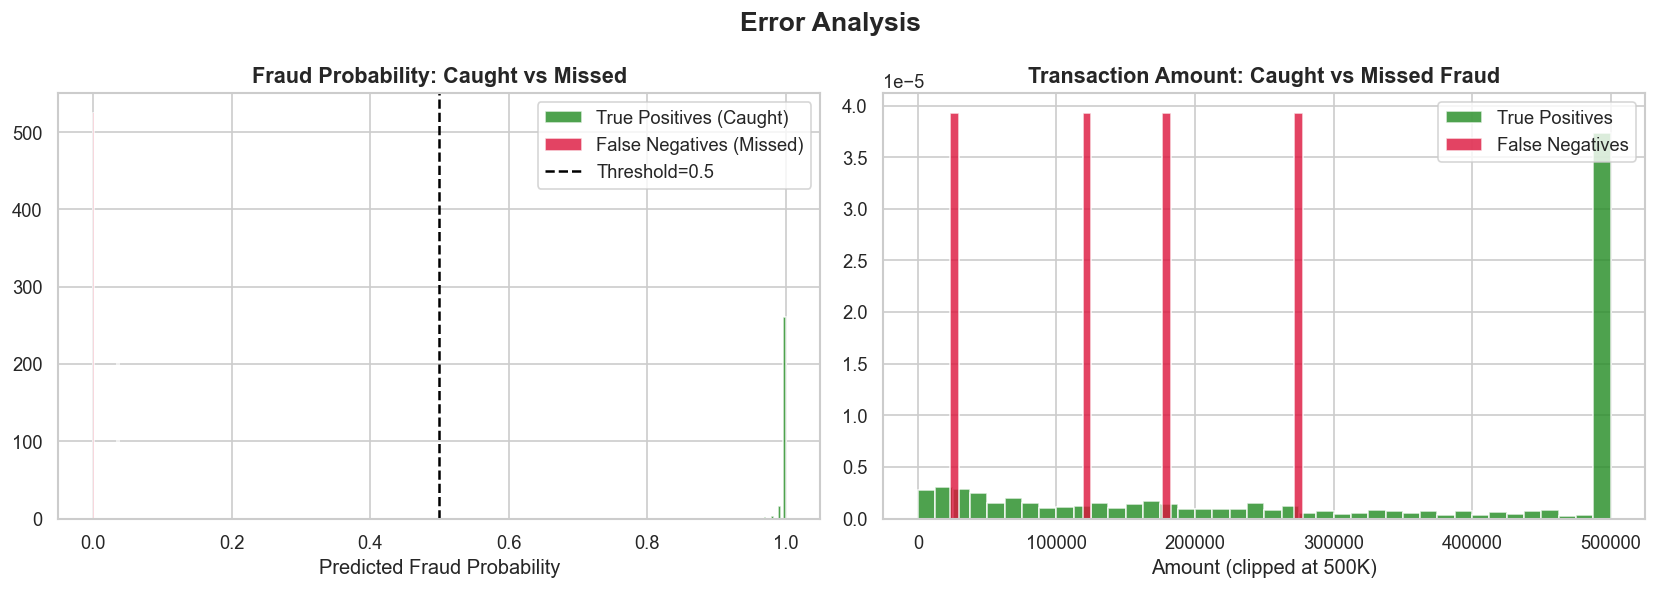

In [14]:
# Probability distribution: TP vs FN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(true_positives['fraud_proba'], bins=40, color='forestgreen',
             alpha=0.8, label='True Positives (Caught)', density=True)
axes[0].hist(false_negatives['fraud_proba'], bins=40, color='crimson',
             alpha=0.8, label='False Negatives (Missed)', density=True)
axes[0].axvline(THRESHOLD, color='black', linestyle='--', label=f'Threshold={THRESHOLD}')
axes[0].set_title('Fraud Probability: Caught vs Missed', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Fraud Probability')
axes[0].legend()

# Amount: TP vs FN
axes[1].hist(true_positives['amount'].clip(upper=5e5), bins=40, color='forestgreen',
             alpha=0.8, label='True Positives', density=True)
axes[1].hist(false_negatives['amount'].clip(upper=5e5), bins=40, color='crimson',
             alpha=0.8, label='False Negatives', density=True)
axes[1].set_title('Transaction Amount: Caught vs Missed Fraud', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Amount (clipped at 500K)')
axes[1].legend()

plt.suptitle('Error Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis.png', bbox_inches='tight')
plt.show()

## 9. 💰 Business Impact Estimation

In [15]:
# Simulate financial impact
# Assumptions (adjust to real costs)
COST_PER_FN = 1.0      # fraction of fraud amount lost when missed
COST_PER_FP = 10.0     # fixed investigation cost per false alarm ($)

original_fraud_amount = analysis_df[analysis_df['isFraud'] == 1]['amount'].sum()
caught_fraud_amount   = true_positives['amount'].sum()
missed_fraud_amount   = false_negatives['amount'].sum()

false_alarm_cost = len(false_positives) * COST_PER_FP

print('💰 BUSINESS IMPACT REPORT')
print('='*50)
print(f'  Total fraud value in test set : ${original_fraud_amount:>15,.2f}')
print(f'  Fraud value CAUGHT            : ${caught_fraud_amount:>15,.2f}')
print(f'  Fraud value MISSED (loss)     : ${missed_fraud_amount:>15,.2f}')
print(f'  Recovery Rate                 : {caught_fraud_amount/original_fraud_amount*100:>14.2f}%')
print('-'*50)
print(f'  False alarms generated        : {len(false_positives):>15,}')
print(f'  False alarm cost (@ ${COST_PER_FP}/each): ${false_alarm_cost:>12,.2f}')
print('-'*50)
print(f'  Net benefit (saved - cost)    : ${caught_fraud_amount - missed_fraud_amount - false_alarm_cost:>15,.2f}')
print('='*50)

💰 BUSINESS IMPACT REPORT
  Total fraud value in test set : $2,382,675,325.93
  Fraud value CAUGHT            : $2,382,069,139.69
  Fraud value MISSED (loss)     : $     606,186.24
  Recovery Rate                 :          99.97%
--------------------------------------------------
  False alarms generated        :               0
  False alarm cost (@ $10.0/each): $        0.00
--------------------------------------------------
  Net benefit (saved - cost)    : $2,381,462,953.45


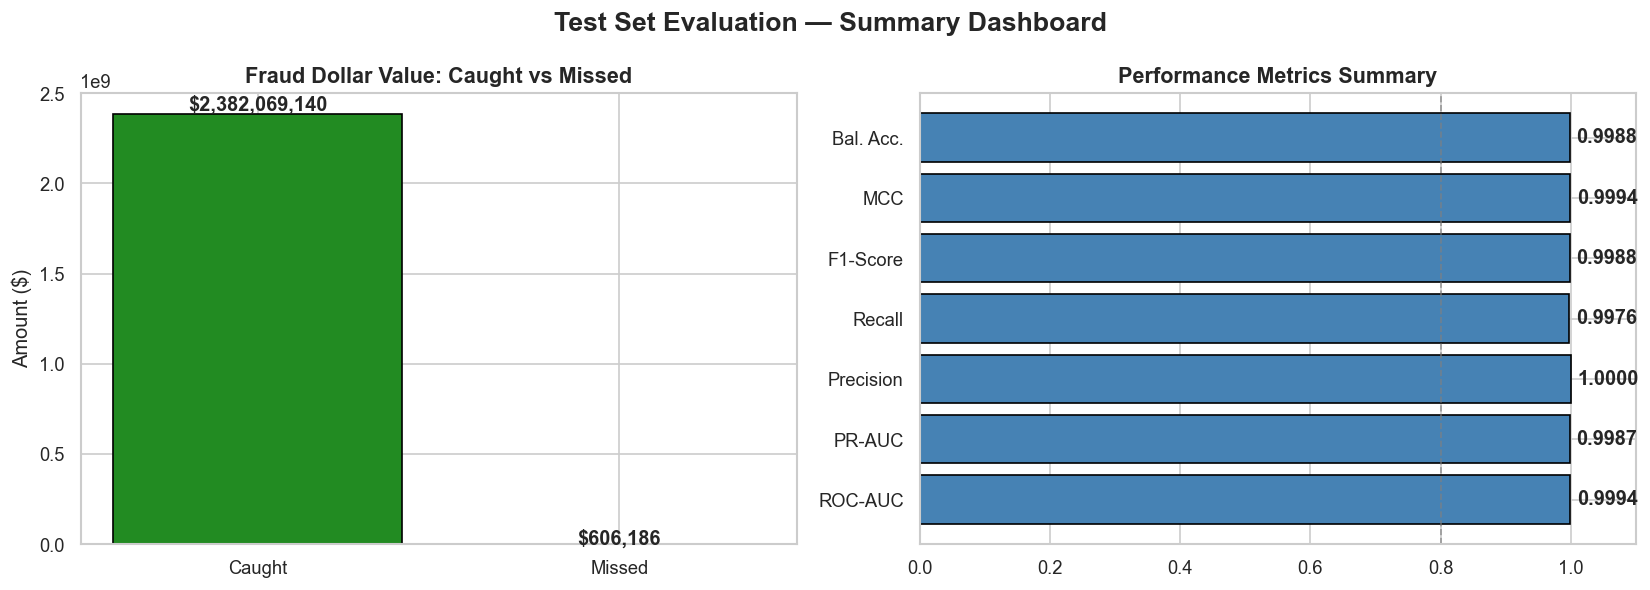

In [16]:
# Visualize business impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud $ caught vs missed
axes[0].bar(['Caught', 'Missed'], [caught_fraud_amount, missed_fraud_amount],
            color=['forestgreen', 'crimson'], edgecolor='black')
axes[0].set_title('Fraud Dollar Value: Caught vs Missed', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amount ($)')
for i, v in enumerate([caught_fraud_amount, missed_fraud_amount]):
    axes[0].text(i, v * 1.01, f'${v:,.0f}', ha='center', fontweight='bold')

# Score summary
metric_names  = ['ROC-AUC', 'PR-AUC', 'Precision', 'Recall', 'F1-Score', 'MCC', 'Bal. Acc.']
metric_values = [roc_auc, pr_auc, prec, rec, f1, (mcc+1)/2, bal_acc]  # MCC normalized
colors_bar    = ['steelblue' if v >= 0.8 else 'orange' if v >= 0.5 else 'crimson'
                 for v in metric_values]

bars = axes[1].barh(metric_names, metric_values, color=colors_bar, edgecolor='black')
axes[1].set_xlim(0, 1.1)
axes[1].axvline(0.8, color='gray', linestyle='--', lw=1, alpha=0.7)
axes[1].set_title('Performance Metrics Summary', fontsize=13, fontweight='bold')
for bar, val in zip(bars, metric_values):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontweight='bold')

plt.suptitle('Test Set Evaluation — Summary Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_dashboard.png', bbox_inches='tight')
plt.show()

## 10. 🔮 Predict on New / Unseen Transactions

In [17]:
def predict_transaction(transaction_dict: dict) -> dict:
    """
    Predict fraud probability for a single transaction.
    
    Parameters
    ----------
    transaction_dict : dict with keys matching FEATURE_COLS
    
    Returns
    -------
    dict with fraud_probability, is_fraud_predicted, risk_level
    """
    df_txn = pd.DataFrame([transaction_dict])
    proba  = model.predict_proba(df_txn)[0, 1]
    pred   = int(proba >= THRESHOLD)
    
    if proba >= 0.8:
        risk = '🔴 HIGH RISK'
    elif proba >= 0.4:
        risk = '🟡 MEDIUM RISK'
    else:
        risk = '🟢 LOW RISK'
    
    return {
        'fraud_probability'  : round(proba, 6),
        'is_fraud_predicted' : bool(pred),
        'risk_level'         : risk
    }


# ── Example transactions ────────────────────────────────────

# Suspicious TRANSFER — balance wiped to 0
suspicious_txn = {
    'step': 1, 'type_encoded': 4, 'amount': 181387.0,
    'oldbalanceOrg': 181387.0, 'newbalanceOrig': 0.0,
    'oldbalanceDest': 0.0, 'newbalanceDest': 0.0,
    'errorBalanceOrig': 0.0, 'errorBalanceDest': -181387.0,
    'amountRatioOrig': 1.0, 'amountRatioDest': 181387.0,
    'origBalanceZero': 1, 'destBalanceUnchanged': 1,
    'hour': 1, 'day': 0
}

# Routine PAYMENT — small amount
normal_txn = {
    'step': 5, 'type_encoded': 3, 'amount': 500.0,
    'oldbalanceOrg': 10000.0, 'newbalanceOrig': 9500.0,
    'oldbalanceDest': 2000.0, 'newbalanceDest': 2500.0,
    'errorBalanceOrig': 0.0, 'errorBalanceDest': 0.0,
    'amountRatioOrig': 0.05, 'amountRatioDest': 0.25,
    'origBalanceZero': 0, 'destBalanceUnchanged': 0,
    'hour': 5, 'day': 0
}

print('🧪 Suspicious TRANSFER:')
result1 = predict_transaction(suspicious_txn)
for k, v in result1.items():
    print(f'   {k}: {v}')

print('\n🧪 Normal PAYMENT:')
result2 = predict_transaction(normal_txn)
for k, v in result2.items():
    print(f'   {k}: {v}')

🧪 Suspicious TRANSFER:
   fraud_probability: 0.96
   is_fraud_predicted: True
   risk_level: 🔴 HIGH RISK

🧪 Normal PAYMENT:
   fraud_probability: 0.0
   is_fraud_predicted: False
   risk_level: 🟢 LOW RISK


## 11. 📋 Final Evaluation Summary

In [18]:
print('╔══════════════════════════════════════════════════════╗')
print('║        FINAL EVALUATION SUMMARY — TEST SET           ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Model          : {type(model).__name__:<35}║')
print(f'║  Test samples   : {len(y_test):>10,}{"":>24}║')
print(f'║  Fraud cases    : {y_test.sum():>10,}{"":>24}║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  ROC-AUC        : {roc_auc:.6f}{"":>29}║')
print(f'║  PR-AUC         : {pr_auc:.6f}{"":>29}║')
print(f'║  Precision      : {prec:.6f}{"":>29}║')
print(f'║  Recall         : {rec:.6f}{"":>29}║')
print(f'║  F1-Score       : {f1:.6f}{"":>29}║')
print(f'║  MCC            : {mcc:.6f}{"":>29}║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  True Positives : {tp:>10,}{"":>24}║')
print(f'║  False Negatives: {fn:>10,}  (fraud missed!)       ║')
print(f'║  False Positives: {fp:>10,}  (false alarms)        ║')
print(f'║  True Negatives : {tn:>10,}{"":>24}║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║        FINAL EVALUATION SUMMARY — TEST SET           ║
╠══════════════════════════════════════════════════════╣
║  Model          : RandomForestClassifier             ║
║  Test samples   :  1,272,524                        ║
║  Fraud cases    :      1,643                        ║
╠══════════════════════════════════════════════════════╣
║  ROC-AUC        : 0.999353                             ║
║  PR-AUC         : 0.998653                             ║
║  Precision      : 1.000000                             ║
║  Recall         : 0.997565                             ║
║  F1-Score       : 0.998781                             ║
║  MCC            : 0.998780                             ║
╠══════════════════════════════════════════════════════╣
║  True Positives :      1,639                        ║
║  False Negatives:          4  (fraud missed!)       ║
║  False Positives:          0  (false alarms)        ║
║  True Negatives :  1,2